In [22]:
%reload_ext autoreload
%autoreload 2

from PIL import Image
from vangogh.evolution import Evolution
from vangogh.fitness import draw_voronoi_image
from vangogh.util import IMAGE_SHRINK_SCALE, REFERENCE_IMAGE
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import seaborn as sns
import collections
import matplotlib.pyplot as plt
from time import time
from mpl_toolkits.axes_grid1 import ImageGrid
plt.style.use('classic')
%matplotlib inline

from multiprocess import Pool, cpu_count

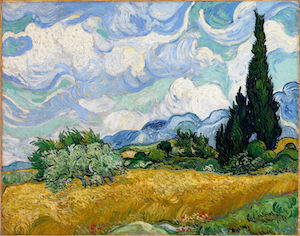

In [23]:
display(REFERENCE_IMAGE)

In [24]:
# Enable to show live rendering of best individual during optimization
display_output = False
# Enable to save progress images at every 50th generation
save_progress = True
# Enable to print verbose output per generation
verbose_output = True

In [25]:
def reporter(time, evo):
    if save_progress or display_output:
        elite = draw_voronoi_image(evo.elite, evo.reference_image.width, evo.reference_image.height, scale=IMAGE_SHRINK_SCALE)
    if display_output:
        clear_output()
        display(elite)
    if save_progress and time["num-generations"] % 50 == 0:
        elite.save(f"./final_img/van_gogh_intermediate_seed{evo.seed}_sel{evo.selection_name}_mutS{evo.num_features_mutation_strength}_{evo.population_size}_{evo.crossover_method}_{evo.num_points}_{evo.initialization}_{evo.generation_budget}_{time['num-generations']:05d}.png")


# my version with selection setting
def run_algorithm(settings):
    seed, population_size, crossover_method, num_points, initialization, generation_budget, selection_name, num_features_mutation_strength = settings
    start = time()
    data = []
    evo = Evolution(num_points,
                    REFERENCE_IMAGE,
                    population_size=population_size,
                    generation_reporter=reporter,
                    crossover_method=crossover_method,
                    seed=seed,
                    initialization=initialization,
                    generation_budget=generation_budget,
                    num_features_mutation_strength=num_features_mutation_strength,#.25,
                    selection_name=selection_name,
                    verbose=verbose_output)
    data = evo.run()
    time_spent = time() - start
    print(f"Done: seed {seed} - pop {population_size} - gen budget {generation_budget} - crossover {crossover_method} - num. points {num_points} - initialization {initialization} - selection {selection_name} - in {int(time_spent)} seconds")
    return data


## Running a single instance

In [5]:
# %%time
# data = run_algorithm((0, 100, "ONE_POINT", 100, 'RANDOM', 500))

## Running a sweep of settings

In [8]:


# generation_budget = 10
# population_size = 100
# crossover_method = "ONE_POINT"
# initialization = "RANDOM"
# num_points = 100
# num_features_mutation_strength = 0.5

# all_results = collections.defaultdict(lambda: collections.defaultdict(list))
# file_name = "truncation_sizes.csv"
# for selection_name, config in selection_experiments.items():
#     for seed in config["seeds"]:
#         print(f"\nRunning {selection_name}, seed {seed}")
#         seed_data = []
#         data = run_algorithm((seed, population_size, crossover_method, num_points, initialization, generation_budget, selection_name,num_features_mutation_strength))
#         seed_data.append(data)
#         all_results[selection_name][seed] = seed_data

## Evaluating the results

In [ ]:
# df = pd.DataFrame(data)
# df["time-elapsed"] = df["time-elapsed"].round(0)

### Different truncation sizes with 5 seeds each

In [37]:
selection_experiments = {
    "truncation_1": {"seeds": list(range(0,100,20))},
    "truncation_5": {"seeds": list(range(0,100,20))},
    "truncation_10": {"seeds": list(range(0,100,20))},
    "truncation_20": {"seeds": list(range(0,100,20))},
    "truncation_40": {"seeds": list(range(0,100,20))},
    "truncation_60": {"seeds": list(range(0,100,20))},
}

In [38]:
import os
import csv

generation_budget = 500
population_size = 100
crossover_method = "ONE_POINT"
initialization = "RANDOM"
num_points = 100
num_features_mutation_strength = 0.5

file_name = "./csv/truncation_sizes_rough.csv"
fieldnames = [
    "selection-name",
    "num-features-mutation-strength",
    "seed",
    "num-generations",
    "num-evaluations",
    "time-elapsed",
    "best-fitness",
    "avg-fitness",
    "crossover-method",
    "population-size",
    "num-points",
    "initialization",
]
if not os.path.isfile(file_name):
    with open(file_name, "w", newline="") as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

# -- 3. your experiment loop, writing out each seed as soon as it’s done --
all_results = collections.defaultdict(lambda: collections.defaultdict(list))
for selection_name, config in selection_experiments.items():
    for seed in config["seeds"]:
        print(f"\nRunning {selection_name}, seed {seed}")

        # run your algorithm and get a list of generation‐records:
        data = run_algorithm((
            seed,
            population_size,
            crossover_method,
            num_points,
            initialization,
            generation_budget,
            selection_name,
            num_features_mutation_strength
        ))
        all_results[selection_name][seed] = data 
        
        with open(file_name, "w", newline="") as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()

            # -- 3. walk your all_results nested defaultdict --
            for selection_name, seeds in all_results.items():
                for seed, records in seeds.items():
                    for rec in records:
                        # build a flat row, mapping your dict-keys into the CSV columns
                        row = {
                            "selection-name": rec.get("selection-name", rec["selection-name"]),
                            "num-features-mutation-strength": rec["num-features-mutation-strength"],
                            "seed": rec.get("seed", seed),
                            "num-generations": rec["num-generations"],
                            "num-evaluations": rec["num-evaluations"],
                            "time-elapsed": rec["time-elapsed"],
                            "best-fitness": int(rec["best-fitness"]),
                            "avg-fitness": float(rec["avg-fitness"]),
                            "crossover-method": rec["crossover-method"],
                            "population-size": rec["population-size"],
                            "num-points": rec["num-points"],
                            "initialization": rec["initialization"],
                        }
                        writer.writerow(row)



Running truncation_1, seed 0
generation: 1 best fitness: 134707 avg. fitness: 135393.28
generation: 2 best fitness: 130439 avg. fitness: 131451.44
generation: 3 best fitness: 128275 avg. fitness: 128349.88
generation: 4 best fitness: 127137 avg. fitness: 127141.6
generation: 5 best fitness: 125546 avg. fitness: 125549.85
generation: 6 best fitness: 124456 avg. fitness: 124554.28
generation: 7 best fitness: 123417 avg. fitness: 123524.64
generation: 8 best fitness: 121327 avg. fitness: 121869.72
generation: 9 best fitness: 119837 avg. fitness: 119837.0
Done: seed 0 - pop 100 - gen budget 500 - crossover ONE_POINT - num. points 100 - initialization RANDOM - selection truncation_1 - in 4 seconds

Running truncation_1, seed 20
generation: 1 best fitness: 136512 avg. fitness: 136992.48
generation: 2 best fitness: 126848 avg. fitness: 127054.08
generation: 3 best fitness: 125626 avg. fitness: 125783.36
generation: 4 best fitness: 123744 avg. fitness: 124040.94
generation: 5 best fitness: 12

In [39]:
import pandas as pd

# load
df = pd.read_csv("./csv/truncation_sizes_rough.csv")

# isolate the “final” row per (selection_method, seed)
#    We sort by generation then take the last row in each group:
final_per_seed = (
    df
    .sort_values("num-generations")
    .groupby(["selection-name", "seed"], as_index=False)
    .last()
)

# final_per_seed

# 3. now group *only* by selection_method and compute mean±std
summary = final_per_seed.groupby("selection-name").agg({
    "best-fitness":     ["mean", "std"],
    "avg-fitness":      ["mean", "std"],
    "num-evaluations":  ["mean", "std"],
    "num-generations":  ["mean", "std"],
}).reset_index()

In [40]:
final_per_seed

,selection-name,seed,num-features-mutation-strength,num-generations,num-evaluations,time-elapsed,best-fitness,avg-fitness,crossover-method,population-size,num-points,initialization
0,truncation_1,0,0.5,9,1000,3.945865,119837,119837.00,ONE_POINT,100,100,RANDOM
1,truncation_1,20,0.5,83,8400,37.709636,73359,73359.00,ONE_POINT,100,100,RANDOM
2,truncation_1,40,0.5,34,3500,15.379452,104292,104292.00,ONE_POINT,100,100,RANDOM
3,truncation_1,60,0.5,15,1600,6.709022,113286,113286.00,ONE_POINT,100,100,RANDOM
4,truncation_1,80,0.5,11,1200,4.830836,113311,113311.00,ONE_POINT,100,100,RANDOM
5,truncation_10,0,0.5,500,50100,226.968677,36316,36341.08,ONE_POINT,100,100,RANDOM
6,truncation_10,20,0.5,410,41100,186.337891,37138,37138.00,ONE_POINT,100,100,RANDOM
7,truncation_10,40,0.5,500,50100,222.217392,34361,34412.14,ONE_POINT,100,100,RANDOM
8,truncation_10,60,0.5,451,45200,198.486381,36871,36871.00,ONE_POINT,100,100,RANDOM
9,truncation_10,80,0.5,414,41500,181.920792,36820,36820.00,ONE_POINT,100,100,RANDOM


In [41]:
summary

selection-name best-fitness               avg-fitness                \
                         mean           std        mean           std   
0   truncation_1     104817.0  18434.707660  104817.000  18434.707660   
1  truncation_10      36301.2   1124.572674   36316.444   1102.614611   
2  truncation_20      38800.0   1223.763049   38845.260   1221.422409   
3  truncation_40      45102.0    940.707181   45228.278    949.303734   
4   truncation_5      75028.8  19664.299471   75028.800  19664.299471   
5  truncation_60      55167.6   1015.449063   55529.900   1025.380225   

  num-evaluations              num-generations             
             mean          std            mean        std  
0          3140.0  3102.901868            30.4  31.029019  
1         45600.0  4407.947368           455.0  44.079474  
2         50100.0     0.000000           500.0   0.000000  
3         50100.0     0.000000           500.0   0.000000  
4         11080.0  6784.320158           109.8  67.843202  
5         50100.0     0.000000           500.0   0.000000

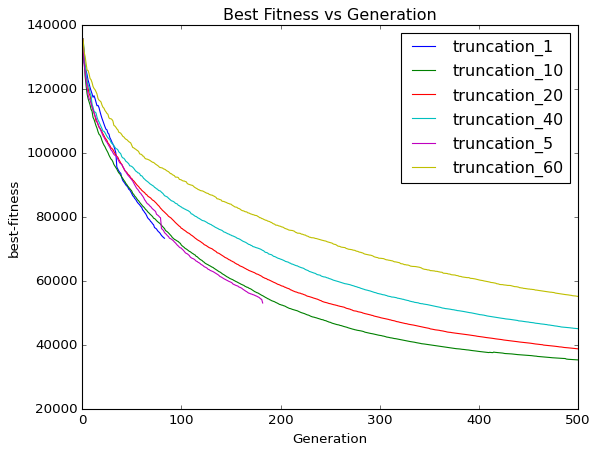

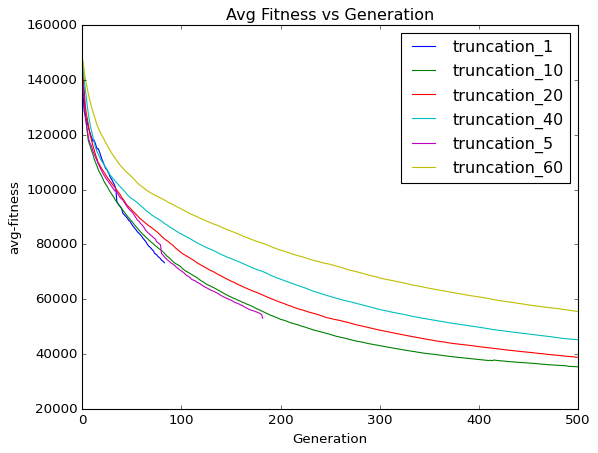

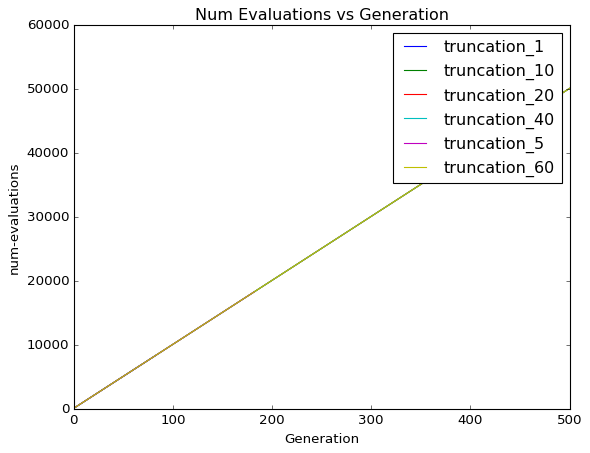

In [56]:
# Compute mean across seeds for each selection method and generation
mean_df = (
    df
    .groupby(["selection-name", "num-generations"], as_index=False)
    .agg({
        "best-fitness": "mean",
        "avg-fitness": "mean",
        "num-evaluations": "mean"
    })
)

methods = mean_df['selection-name'].unique()


# Plot each metric
for metric in ["best-fitness", "avg-fitness", "num-evaluations"]:
    plt.figure()
    for method in methods:
        sub = mean_df[mean_df["selection-name"] == method]
        plt.plot(sub["num-generations"], sub[metric], label=method)
    plt.xlabel("Generation")
    plt.ylabel(metric)
    plt.title(f"{metric.replace('-', ' ').title()} vs Generation")
    plt.legend()
    plt.show()

Highest possible selection pressure with full 500 generations of run we get only with truncation_10.
truncation_1, truncation_5 also have very high pressure but they converge too early - probably due to drasctic fall in diversity. 

Maybe we can avoid the pitfalls of early convergence, while keeping the benefits of high pressure if we can just maintain the diversity over generations.
- confirm this current behaviour over 30 seeds - 1,5,10,20,40 trunc
- run 30 seeds + 0.75 mutation strength - for 1,5,10 trunc
- run 10 seeds ssga selection + 0.50 mut - for 1,5,10 trunc + tournament best sizes 2 (if tournament has early convergence issue too)
- run 30 seeds with the best 4 methods of last ssga one


### Different Truncation sizes with 30 seeds (confirmation)

In [108]:
selection_experiments = {
    "truncation_1": {"seeds": list(range(0,600,20))},
    "truncation_5": {"seeds": list(range(0,600,20))},
    "truncation_10": {"seeds": list(range(460,600,20))},
    "truncation_20": {"seeds": list(range(0,600,20))},
    "truncation_40": {"seeds": list(range(0,600,20))},
    # "truncation_60": {"seeds": list(range(0,600,20))},
}

In [34]:
import os
import csv

generation_budget = 500
population_size = 100
crossover_method = "ONE_POINT"
initialization = "RANDOM"
num_points = 100
num_features_mutation_strength = 0.5

file_name = "./csv/truncation_sizes_30_seeds.csv"
fieldnames = [
    "selection-name",
    "num-features-mutation-strength",
    "seed",
    "num-generations",
    "num-evaluations",
    "time-elapsed",
    "best-fitness",
    "avg-fitness",
    "crossover-method",
    "population-size",
    "num-points",
    "initialization",
]
if not os.path.isfile(file_name):
    with open(file_name, "w", newline="") as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

# -- 3. your experiment loop, writing out each seed as soon as it’s done --
all_results = collections.defaultdict(lambda: collections.defaultdict(list))
for selection_name, config in selection_experiments.items():
    for seed in config["seeds"]:
        print(f"\nRunning {selection_name}, seed {seed}")

        # run your algorithm and get a list of generation‐records:
        data = run_algorithm((
            seed,
            population_size,
            crossover_method,
            num_points,
            initialization,
            generation_budget,
            selection_name,
            num_features_mutation_strength
        ))
        all_results[selection_name][seed] = data 
        
        with open(file_name, "w", newline="") as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()

            # -- 3. walk your all_results nested defaultdict --
            for selection_name, seeds in all_results.items():
                for seed, records in seeds.items():
                    for rec in records:
                        # build a flat row, mapping your dict-keys into the CSV columns
                        row = {
                            "selection-name": rec.get("selection-name", rec["selection-name"]),
                            "num-features-mutation-strength": rec["num-features-mutation-strength"],
                            "seed": rec.get("seed", seed),
                            "num-generations": rec["num-generations"],
                            "num-evaluations": rec["num-evaluations"],
                            "time-elapsed": rec["time-elapsed"],
                            "best-fitness": int(rec["best-fitness"]),
                            "avg-fitness": float(rec["avg-fitness"]),
                            "crossover-method": rec["crossover-method"],
                            "population-size": rec["population-size"],
                            "num-points": rec["num-points"],
                            "initialization": rec["initialization"],
                        }
                        writer.writerow(row)



Running truncation_1, seed 0
generation: 1 best fitness: 134707 avg. fitness: 135393.28
generation: 2 best fitness: 130439 avg. fitness: 131451.44
generation: 3 best fitness: 128275 avg. fitness: 128349.88
generation: 4 best fitness: 127137 avg. fitness: 127141.6
generation: 5 best fitness: 125546 avg. fitness: 125549.85
generation: 6 best fitness: 124456 avg. fitness: 124554.28
generation: 7 best fitness: 123417 avg. fitness: 123524.64
generation: 8 best fitness: 121327 avg. fitness: 121869.72
generation: 9 best fitness: 119837 avg. fitness: 119837.0
Done: seed 0 - pop 100 - gen budget 500 - crossover ONE_POINT - num. points 100 - initialization RANDOM - selection truncation_1 - in 3 seconds

Running truncation_1, seed 20
generation: 1 best fitness: 136512 avg. fitness: 136992.48
generation: 2 best fitness: 126848 avg. fitness: 127054.08
generation: 3 best fitness: 125626 avg. fitness: 125783.36
generation: 4 best fitness: 123744 avg. fitness: 124040.94
generation: 5 best fitness: 12

In [109]:
import pandas as pd

# load
file_name = "./csv/truncation_sizes_30_seeds.csv"
df = pd.read_csv(file_name)


# isolate the “final” row per (selection_method, seed)
#    We sort by generation then take the last row in each group:
final_per_seed = (
    df
    .sort_values("num-generations")
    .groupby(["selection-name", "seed"], as_index=False)
    .last()
)



# 3. now group *only* by selection_method and compute mean±std
summary = final_per_seed.groupby("selection-name").agg({
    "best-fitness":     ["mean", "std"],
    "avg-fitness":      ["mean", "std"],
    "num-evaluations":  ["mean", "std"],
    "num-generations":  ["mean", "std"],
}).reset_index()

summary

selection-name   best-fitness                  avg-fitness                \
                           mean           std           mean           std   
0   truncation_1  103295.533333  13104.573302  103295.533333  13104.573302   
1  truncation_10   38313.571429   2146.315359   38323.444286   2140.378689   
2  truncation_20   38848.766667   1281.859659   38911.733333   1286.179654   
3  truncation_40   45649.533333   1543.655106   45807.684000   1560.384000   
4   truncation_5   80906.600000  21475.032159   80906.600000  21475.032159   

  num-evaluations              num-generations             
             mean          std            mean        std  
0     3336.666667  1865.380304       32.366667  18.653803  
1    43142.857143  7970.331892      430.428571  79.703319  
2    50100.000000     0.000000      500.000000   0.000000  
3    50100.000000     0.000000      500.000000   0.000000  
4     9266.666667  6356.931234       91.666667  63.569312

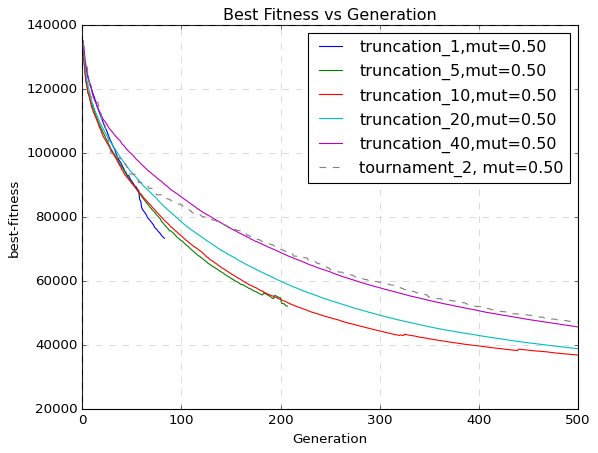

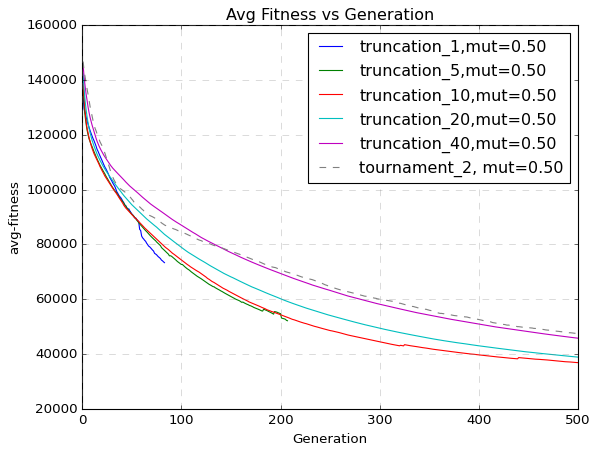

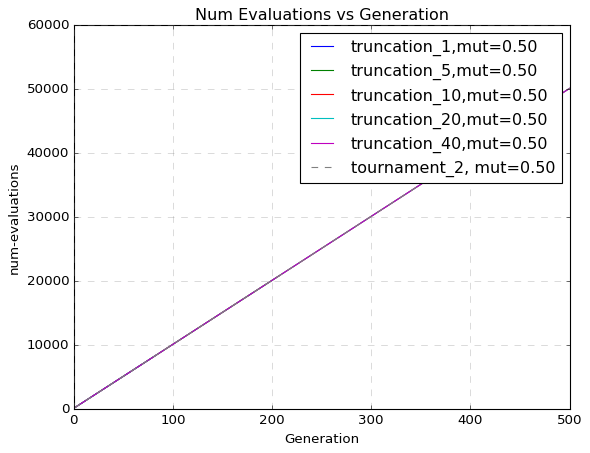

In [110]:
# Compute mean across seeds for each selection method and generation
mean_df = (
    df
    .groupby(["selection-name", "num-generations"], as_index=False)
    .agg({
        "best-fitness": "mean",
        "avg-fitness": "mean",
        "num-evaluations": "mean"
    })
)

methods = mean_df['selection-name'].unique()

# load baseline
df_base = pd.read_csv("./csv/base50.csv")

# compute baseline mean per generation
base_mean_df = (
    df_base
    .groupby("num-generations", as_index=False)
    .agg({
        "best-fitness":     "mean",
        "avg-fitness":      "mean",
        "num-evaluations":  "mean"
    })
)
import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor']   = 'white'
# turn on major grid by default
mpl.rcParams['axes.grid']        = True
# optional: set style of those grid‐lines
mpl.rcParams['grid.linestyle']   = '--'
mpl.rcParams['grid.color']       = 'grey'
mpl.rcParams['grid.alpha']       = 0.5

# Plot each metric
for metric in ["best-fitness", "avg-fitness", "num-evaluations"]:
    plt.figure()
    for method in selection_experiments.keys():
        # if method == "truncation_5":
        #     continue
        sub = mean_df[mean_df["selection-name"] == method]
        plt.plot(sub["num-generations"], sub[metric], label=method+",mut=0.50")

    # plot baseline
    plt.plot(base_mean_df["num-generations"],
             base_mean_df[metric],
             linestyle='--',
             color='grey',
             label='tournament_2, mut=0.50')
    
    plt.xlabel("Generation")
    plt.ylabel(metric)
    plt.title(f"{metric.replace('-', ' ').title()} vs Generation")
    plt.legend()
    plt.show()

### Best of trunction sizes + 0.75 mutation - 30 seeds

In [111]:
file_name = "./csv/truncation_sizes_mut_075_30_seeds.csv"

In [112]:
selection_experiments = {
    "truncation_1": {"seeds": list(range(0,600,20))},
    "truncation_5": {"seeds": list(range(0,600,20))},
    "truncation_10": {"seeds": list(range(0,600,20))},
}

In [32]:
import os
import csv

generation_budget = 500
population_size = 100
crossover_method = "ONE_POINT"
initialization = "RANDOM"
num_points = 100
num_features_mutation_strength = 0.75

fieldnames = [
    "selection-name",
    "num-features-mutation-strength",
    "seed",
    "num-generations",
    "num-evaluations",
    "time-elapsed",
    "best-fitness",
    "avg-fitness",
    "crossover-method",
    "population-size",
    "num-points",
    "initialization",
]
if not os.path.isfile(file_name):
    with open(file_name, "w", newline="") as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

# -- 3. your experiment loop, writing out each seed as soon as it’s done --
all_results = collections.defaultdict(lambda: collections.defaultdict(list))
for selection_name, config in selection_experiments.items():
    for seed in config["seeds"]:
        print(f"\nRunning {selection_name}, seed {seed}")

        # run your algorithm and get a list of generation‐records:
        data = run_algorithm((
            seed,
            population_size,
            crossover_method,
            num_points,
            initialization,
            generation_budget,
            selection_name,
            num_features_mutation_strength
        ))
        all_results[selection_name][seed] = data 
        
        with open(file_name, "w", newline="") as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()

            # -- 3. walk your all_results nested defaultdict --
            for selection_name, seeds in all_results.items():
                for seed, records in seeds.items():
                    for rec in records:
                        # build a flat row, mapping your dict-keys into the CSV columns
                        row = {
                            "selection-name": rec.get("selection-name", rec["selection-name"]),
                            "num-features-mutation-strength": rec["num-features-mutation-strength"],
                            "seed": rec.get("seed", seed),
                            "num-generations": rec["num-generations"],
                            "num-evaluations": rec["num-evaluations"],
                            "time-elapsed": rec["time-elapsed"],
                            "best-fitness": int(rec["best-fitness"]),
                            "avg-fitness": float(rec["avg-fitness"]),
                            "crossover-method": rec["crossover-method"],
                            "population-size": rec["population-size"],
                            "num-points": rec["num-points"],
                            "initialization": rec["initialization"],
                        }
                        writer.writerow(row)



Running truncation_1, seed 0
generation: 1 best fitness: 134707 avg. fitness: 135393.28
generation: 2 best fitness: 131773 avg. fitness: 131960.03
generation: 3 best fitness: 127630 avg. fitness: 127793.8
generation: 4 best fitness: 125882 avg. fitness: 126018.16
generation: 5 best fitness: 123289 avg. fitness: 123486.45
generation: 6 best fitness: 120890 avg. fitness: 121269.26
generation: 7 best fitness: 119779 avg. fitness: 120143.0
generation: 8 best fitness: 118048 avg. fitness: 118747.6
generation: 9 best fitness: 117482 avg. fitness: 117581.0
generation: 10 best fitness: 116167 avg. fitness: 116533.85
generation: 11 best fitness: 115440 avg. fitness: 115441.59
generation: 12 best fitness: 113442 avg. fitness: 114033.26
generation: 13 best fitness: 112422 avg. fitness: 112650.43
generation: 14 best fitness: 111701 avg. fitness: 111774.44
generation: 15 best fitness: 111203 avg. fitness: 111217.4
generation: 16 best fitness: 110124 avg. fitness: 110231.5
generation: 17 best fitne

In [113]:
import pandas as pd

file_name ="./csv/truncation_sizes_mut_075_30_seeds.csv"
df = pd.read_csv(file_name)

# isolate the “final” row per (selection_method, seed)
#    We sort by generation then take the last row in each group:
final_per_seed = (
    df
    .sort_values("num-generations")
    .groupby(["selection-name", "seed"], as_index=False)
    .last()
)

# final_per_seed

# 3. now group *only* by selection_method and compute mean±std
summary = final_per_seed.groupby("selection-name").agg({
    "best-fitness":     ["mean", "std"],
    "avg-fitness":      ["mean", "std"],
    "num-evaluations":  ["mean", "std"],
    "num-generations":  ["mean", "std"],
}).reset_index()

summary

selection-name   best-fitness                  avg-fitness                \
                           mean           std           mean           std   
0   truncation_1  103281.133333  15534.789314  103281.133333  15534.789314   
1  truncation_10   41651.533333   6147.427692   41656.727667   6142.944149   
2   truncation_5   78908.433333  21627.282846   78908.433333  21627.282846   

  num-evaluations               num-generations              
             mean           std            mean         std  
0     3040.000000   2171.063620       29.400000   21.710636  
1    38336.666667  11583.831875      382.366667  115.838319  
2     9196.666667   6641.067806       90.966667   66.410678

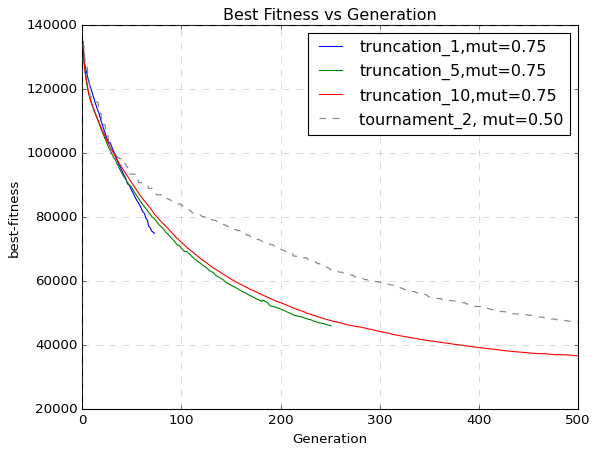

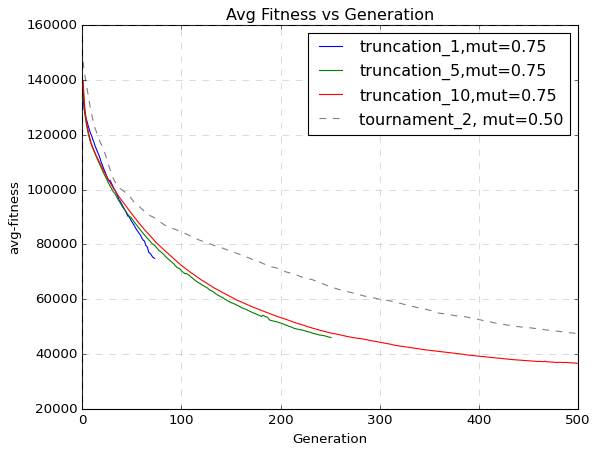

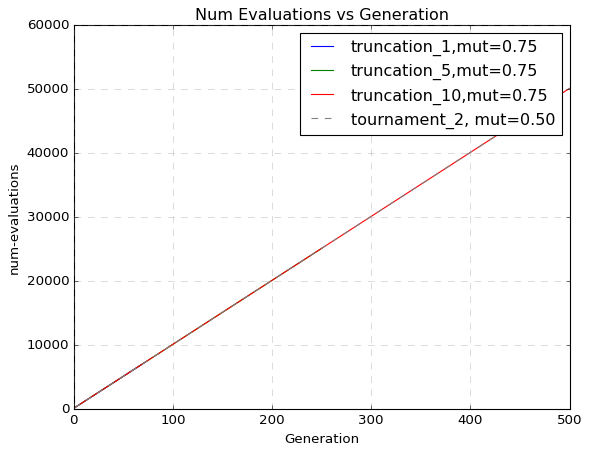

In [114]:
# Compute mean across seeds for each selection method and generation
mean_df = (
    df
    .groupby(["selection-name", "num-generations"], as_index=False)
    .agg({
        "best-fitness": "mean",
        "avg-fitness": "mean",
        "num-evaluations": "mean"
    })
)



# methods = mean_df['selection-name'].unique()

import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor']   = 'white'
# turn on major grid by default
mpl.rcParams['axes.grid']        = True
# optional: set style of those grid‐lines
mpl.rcParams['grid.linestyle']   = '--'
mpl.rcParams['grid.color']       = 'grey'
mpl.rcParams['grid.alpha']       = 0.5

# load baseline
df_base = pd.read_csv("./csv/base50.csv")

# compute baseline mean per generation
base_mean_df = (
    df_base
    .groupby("num-generations", as_index=False)
    .agg({
        "best-fitness":     "mean",
        "avg-fitness":      "mean",
        "num-evaluations":  "mean"
    })
)
# Plot each metric
for metric in ["best-fitness", "avg-fitness", "num-evaluations"]:
    plt.figure()
    for method in selection_experiments.keys():
        # if method == "truncation_5":
        #     continue
        sub = mean_df[mean_df["selection-name"] == method]
        plt.plot(sub["num-generations"], sub[metric], label=method+",mut=0.75")

    # plot baseline
    plt.plot(base_mean_df["num-generations"],
             base_mean_df[metric],
             linestyle='--',
             color='grey',
             label='tournament_2, mut=0.50')
    
    plt.xlabel("Generation")
    plt.ylabel(metric)
    plt.title(f"{metric.replace('-', ' ').title()} vs Generation")
    plt.legend()
    plt.show()

## Displaying the best instances over time

In [11]:
# def show_progress_over_time(settings, selection=None, grid=(5,4)):
#     seed, population_size, crossover_method, num_points, generation_budget = settings
#     fig = plt.figure(figsize=(20., 20.))
#     grid = ImageGrid(fig, 111, 
#                      nrows_ncols=grid,
#                      axes_pad=0.1,  # pad between axes
#                      )

#     if selection is None:
#         selection = range(50, generation_budget + 50, 50)
    
#     img_arr = [Image.open((f"./img/van_gogh_intermediate_{seed}_{population_size}_{crossover_method}_{num_points}_{generation_budget}_{i:05d}.png")) for i in selection]
#     for ax, im in zip(grid, img_arr):
#         ax.imshow(im)
#         ax.get_xaxis().set_visible(False)
#         ax.get_yaxis().set_visible(False)

#     plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './img/van_gogh_intermediate_0_100_ONE_POINT_100_500_00050.png'

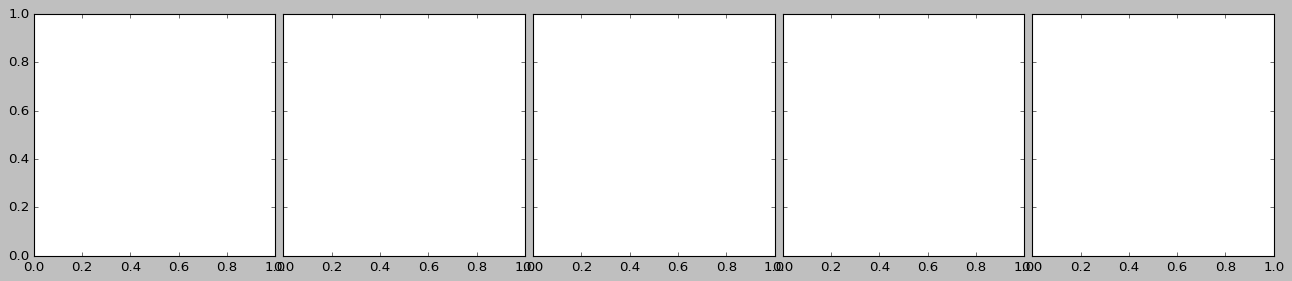

In [12]:
# show_progress_over_time((0, 100, 'ONE_POINT', 100, 500), grid=(1,5))